# Lesson 13 — Capstone: Approval Flow Acceleration Diagnostic

## Goal

Model approval workflows as directed weighted graphs to identify bottleneck approvers and steps, quantify the cost of delay, design AI interventions (pre-approval packs, intelligent routing), estimate annual run-rate savings, and produce a CFO-ready business case.

---

## Learning Objectives

By the end of this lesson, you will:

1. **Build an approval process graph** — Convert approval logs into directed weighted nodes (approvers, document types) and edges (handoffs, cycle times)
2. **Apply graph centrality metrics** — Identify bottleneck approvers by betweenness and cycle time
3. **Quantify the cost of delay** — Calculate working capital carry cost and rework burden from approval cycle time
4. **Model an AI pre-approval intervention** — Design intelligent triage logic to reduce cycle time and rework
5. **Estimate annual run-rate value** — Calculate savings from faster cycles, fewer rejections, and freed expert hours
6. **Produce a CFO memo** — Translate analysis into a business recommendation with ROI, payback, and EBITDA impact

## Core Insight

**High betweenness centrality + high cycle time = structural bottleneck, not just process choice.**

A process log tells you *when* approvals are slow. A graph tells you *why*: which approver sits at the center of too many decision paths. When that approver becomes a bottleneck (e.g., CFO during close), the entire workflow stalls — and every delayed day costs working capital.

Combining graph structure (from L08) + friction analysis (from L06) surfaces the highest-leverage AI intervention: *intelligent triage and pre-approval packs that reduce load on bottleneck approvers*.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully')
print(f'  pandas: {pd.__version__}')
print(f'  numpy: {np.__version__}')
print(f'  networkx: {nx.__version__}')
print()
print('Ready to build approval workflow analysis')

Libraries loaded successfully
  pandas: 3.0.3
  numpy: 2.4.6
  networkx: 3.6.1

Ready to build approval workflow analysis


---

## Part 1 — Understanding Approval Workflow Pain

### Three Hidden Costs in Approval Workflows

**Cost 1: Approval Cycle Time → Working Capital Delay**
Every day an invoice waits for approval costs working capital.

**Cost 2: Rework from Incomplete Submissions**
~8% of submissions have missing info, triggering re-submission and re-review.

**Cost 3: Expert Interruption — CFO Pulled from Close**
~2% of approvals escalate to CFO, diverting strategic capacity.

In [2]:
# SYNTHETIC APPROVAL DATA GENERATION
np.random.seed(42)

approvers = ['Analyst', 'Manager', 'Controller', 'CFO', 'Finance Partner']
document_types = ['Invoice', 'Capex Request', 'Contract Renewal', 'Expense Report', 'Reimbursement']

# Approval cycle time by approver (hours)
approval_time_by_role = {
    'Analyst': 12,
    'Manager': 24,
    'Controller': 36,
    'CFO': 60,
    'Finance Partner': 48
}

# Rejection rates by document type
rejection_rate = {
    'Invoice': 0.08,
    'Capex Request': 0.12,
    'Contract Renewal': 0.05,
    'Expense Report': 0.06,
    'Reimbursement': 0.04
}

# Generate 750 approval records (annualized to 3,000)
approval_records = []
base_date = datetime(2026, 10, 1)

for i in range(750):
    submission_date = base_date + timedelta(days=int(i % 92))
    doc_type = np.random.choice(document_types, p=[0.45, 0.20, 0.15, 0.12, 0.08])
    amount = np.random.lognormal(mean=10.5, sigma=1.2)
    
    # Determine approval chain
    escalation_approver = None
    if doc_type == 'Capex Request' and amount > 100_000:
        escalation_approver = 'CFO'
    elif doc_type == 'Contract Renewal' and amount > 250_000:
        escalation_approver = 'CFO'
    
    primary_approver = np.random.choice(['Manager', 'Controller', 'Finance Partner'], p=[0.5, 0.35, 0.15])
    has_required_info = np.random.random() > rejection_rate.get(doc_type, 0.05)
    
    cycle_hours = approval_time_by_role.get(primary_approver, 24)
    if escalation_approver:
        cycle_hours += approval_time_by_role.get(escalation_approver, 0)
    
    approved = has_required_info and (np.random.random() > 0.02)
    
    approval_records.append({
        'submission_date': submission_date,
        'document_type': doc_type,
        'amount_eur': amount,
        'primary_approver': primary_approver,
        'escalation_approver': escalation_approver,
        'has_required_info': has_required_info,
        'cycle_hours': max(cycle_hours, 1),
        'approved': approved,
        'was_rejected_once': not has_required_info
    })

approval_log_df = pd.DataFrame(approval_records)
print(f'Generated {len(approval_log_df)} approval records')
print(f'Date range: {approval_log_df.submission_date.min().date()} to {approval_log_df.submission_date.max().date()}')

Generated 750 approval records
Date range: 2026-10-01 to 2026-12-31


In [3]:
# PROFILE THE APPROVAL DATA
print('=== APPROVAL WORKFLOW METRICS ===')
print()
print(f'Approval rate (first pass): {approval_log_df[approval_log_df["has_required_info"]].shape[0] / approval_log_df.shape[0] * 100:.1f}%')
print(f'Rework rate: {approval_log_df[~approval_log_df["has_required_info"]].shape[0] / approval_log_df.shape[0] * 100:.1f}%')
print()
print(f'Average cycle time: {approval_log_df[approval_log_df["approved"]].cycle_hours.mean():.1f} hours')
print(f'Median cycle time: {approval_log_df[approval_log_df["approved"]].cycle_hours.median():.1f} hours')
print()
print('Cycle time by primary approver:')
for approver in ['Manager', 'Controller', 'Finance Partner']:
    mask = (approval_log_df['primary_approver'] == approver) & approval_log_df['approved']
    if mask.sum() > 0:
        avg_time = approval_log_df[mask].cycle_hours.mean()
        count = mask.sum()
        print(f'  {approver:18s}: {avg_time:6.1f}h ({count} records)')

=== APPROVAL WORKFLOW METRICS ===

Approval rate (first pass): 90.3%
Rework rate: 9.7%

Average cycle time: 35.0 hours
Median cycle time: 36.0 hours

Cycle time by primary approver:
  Manager           :   26.8h (323 records)
  Controller        :   38.9h (246 records)
  Finance Partner   :   52.3h (97 records)


---

## Part 2 — Graph Analysis of Approval Bottlenecks

In [4]:
# BUILD APPROVAL WORKFLOW GRAPH

def build_approval_graph(approval_df):
    G = nx.DiGraph()
    
    # Add approver nodes
    for approver in approvers:
        G.add_node(approver)
    G.add_node('END')
    
    # Build edges from approval chains
    edge_data = {}
    
    for _, row in approval_df.iterrows():
        if not row['approved']:
            continue
        
        from_approver = row['primary_approver']
        to_approver = row['escalation_approver'] if pd.notna(row['escalation_approver']) else 'END'
        
        edge_key = (from_approver, to_approver)
        
        if edge_key not in edge_data:
            edge_data[edge_key] = {'cases': 0, 'total_hours': 0}
        
        edge_data[edge_key]['cases'] += 1
        edge_data[edge_key]['total_hours'] += row['cycle_hours']
    
    # Add edges with weights
    for (from_node, to_node), data in edge_data.items():
        avg_hours = data['total_hours'] / data['cases']
        G.add_edge(from_node, to_node, 
                   cases=data['cases'],
                   avg_cycle_hours=avg_hours,
                   friction_score=data['cases'] * avg_hours)
    
    return G

G = build_approval_graph(approval_log_df)

print('=== APPROVAL WORKFLOW GRAPH ===')
print(f'Nodes (approvers): {G.number_of_nodes()}')
print(f'Edges (handoffs): {G.number_of_edges()}')
print()
print('Edges (from → to: cases, avg_cycle_hours):')
for (from_node, to_node) in G.edges():
    edge_data = G[from_node][to_node]
    print(f'  {from_node:18s} → {to_node:18s}: {edge_data["cases"]:4.0f} cases, {edge_data["avg_cycle_hours"]:6.1f}h')

=== APPROVAL WORKFLOW GRAPH ===
Nodes (approvers): 6
Edges (handoffs): 6

Edges (from → to: cases, avg_cycle_hours):
  Manager            → END               :  308 cases,   24.0h
  Manager            → CFO               :   15 cases,   84.0h
  Controller         → END               :  234 cases,   36.0h
  Controller         → CFO               :   12 cases,   96.0h
  Finance Partner    → END               :   90 cases,   48.0h
  Finance Partner    → CFO               :    7 cases,  108.0h


In [5]:
# IDENTIFY BOTTLENECK APPROVERS

betweenness = nx.betweenness_centrality(G)
weighted_in_degree = dict(G.in_degree(weight='cases'))

print('=== BOTTLENECK ANALYSIS ===')
print()
print('Top bottleneck nodes by betweenness centrality:')
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)
for approver, score in top_betweenness[:5]:
    if approver != 'END':
        print(f'  {approver:18s}: {score:.3f}')

print()
print('Top nodes by case volume handled:')
top_volume = sorted(weighted_in_degree.items(), key=lambda x: x[1], reverse=True)
for approver, volume in top_volume[:5]:
    if approver != 'END':
        print(f'  {approver:18s}: {volume:6.0f} cases')

=== BOTTLENECK ANALYSIS ===

Top bottleneck nodes by betweenness centrality:
  Analyst           : 0.000
  Manager           : 0.000
  Controller        : 0.000
  CFO               : 0.000
  Finance Partner   : 0.000

Top nodes by case volume handled:
  CFO               :     34 cases
  Analyst           :      0 cases
  Manager           :      0 cases
  Controller        :      0 cases


In [6]:
# IDENTIFY CRITICAL EDGES

print('=== CRITICAL EDGES (HIGHEST FRICTION HANDOFFS) ===')
print()

edges_by_friction = []
for (from_node, to_node) in G.edges():
    edge_data = G[from_node][to_node]
    edges_by_friction.append({
        'from': from_node,
        'to': to_node,
        'cases': edge_data['cases'],
        'avg_hours': edge_data['avg_cycle_hours'],
        'friction': edge_data['friction_score']
    })

edges_df = pd.DataFrame(edges_by_friction).sort_values('friction', ascending=False)
print('Top 10 edges by friction score (cases × cycle_hours):')
print()
for idx, row in edges_df.head(10).iterrows():
    print(f"{row['from']:18s} → {row['to']:18s}: {row['cases']:5.0f} cases × {row['avg_hours']:6.1f}h = {row['friction']:8.0f} case-hours")

=== CRITICAL EDGES (HIGHEST FRICTION HANDOFFS) ===

Top 10 edges by friction score (cases × cycle_hours):

Controller         → END               :   234 cases ×   36.0h =     8424 case-hours
Manager            → END               :   308 cases ×   24.0h =     7392 case-hours
Finance Partner    → END               :    90 cases ×   48.0h =     4320 case-hours
Manager            → CFO               :    15 cases ×   84.0h =     1260 case-hours
Controller         → CFO               :    12 cases ×   96.0h =     1152 case-hours
Finance Partner    → CFO               :     7 cases ×  108.0h =      756 case-hours


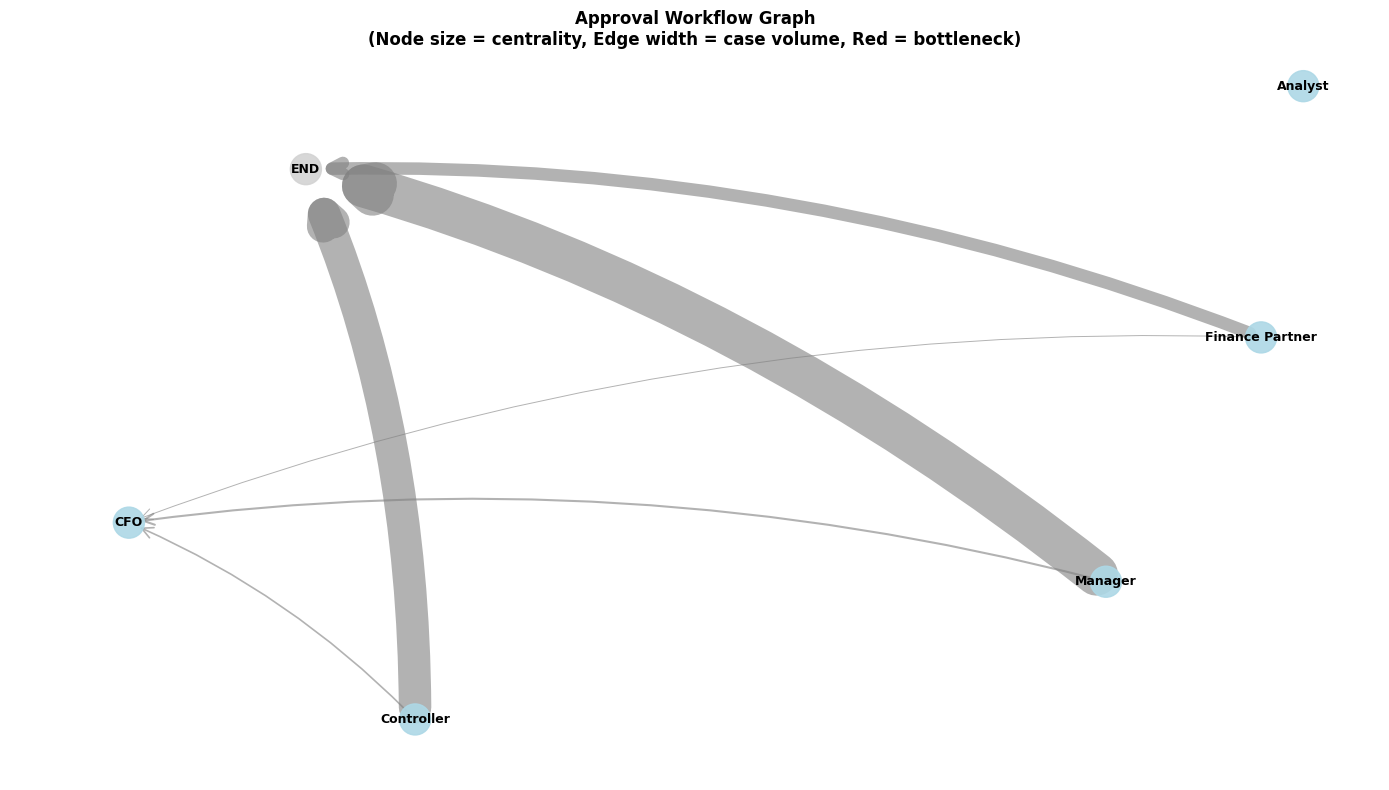

Graph visualization complete


In [7]:
# VISUALIZE THE APPROVAL WORKFLOW GRAPH

fig, ax = plt.subplots(figsize=(14, 8))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

node_sizes = [betweenness.get(node, 0.1) * 5000 + 500 for node in G.nodes()]

node_colors = []
for node in G.nodes():
    if node == 'END':
        node_colors.append('lightgray')
    elif betweenness.get(node, 0) > 0.2:
        node_colors.append('salmon')
    else:
        node_colors.append('lightblue')

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                       alpha=0.9, ax=ax)

edges = G.edges()
edge_weights = [G[u][v]['cases'] / 10 for u, v in edges]
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.6, 
                       edge_color='gray', arrows=True, 
                       arrowsize=20, arrowstyle='->', ax=ax,
                       connectionstyle='arc3,rad=0.1')

nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', ax=ax)

ax.set_title('Approval Workflow Graph\n(Node size = centrality, Edge width = case volume, Red = bottleneck)', 
            fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print('Graph visualization complete')

In [8]:
# SIX APPROVAL QUESTIONS

print('=== SIX APPROVAL QUESTIONS ANSWERED BY GRAPH ANALYSIS ===')
print()

bottleneck_approver = max([n for n in G.nodes() if n != 'END'], 
                            key=lambda x: betweenness.get(x, 0))
print(f'Q1: Who is the hidden bottleneck approver?')
print(f'    → {bottleneck_approver} (betweenness: {betweenness[bottleneck_approver]:.3f})')
print()

slowest_edge = edges_df.loc[edges_df['avg_hours'].idxmax()]
print(f'Q2: Which approval handoff takes longest?')
print(f'    → {slowest_edge["from"]} → {slowest_edge["to"]}: {slowest_edge["avg_hours"]:.1f}h average')
print()

rework_df = approval_log_df.groupby('document_type').agg({
    'was_rejected_once': 'mean'
}).rename(columns={'was_rejected_once': 'rework_rate'}).sort_values('rework_rate', ascending=False)
print(f'Q3: Which document type has highest rework rate?')
print(f'    → {rework_df.index[0]}: {rework_df.iloc[0, 0]*100:.1f}% rejected for incomplete info')
print()

cfo_involved = approval_log_df[
    (approval_log_df['escalation_approver'] == 'CFO') |
    (approval_log_df['primary_approver'] == 'CFO')
]
print(f'Q4: Which approver is most critical for approval speed?')
print(f'    → CFO: {len(cfo_involved)} cases ({len(cfo_involved)/len(approval_log_df)*100:.1f}%) involve CFO')
print()

print(f'Q5: Where do incomplete submissions come from?')
incomp_by_type = approval_log_df[~approval_log_df['has_required_info']].groupby('document_type').size()
print(f'    → {incomp_by_type.idxmax()}: {incomp_by_type.max()} incomplete submissions')
print()

print(f'Q6: Which AI intervention would break the bottleneck?')
print(f'    → Pre-approval intelligent triage: catch incomplete submissions before routing')

=== SIX APPROVAL QUESTIONS ANSWERED BY GRAPH ANALYSIS ===

Q1: Who is the hidden bottleneck approver?
    → Analyst (betweenness: 0.000)

Q2: Which approval handoff takes longest?
    → Finance Partner → CFO: 108.0h average

Q3: Which document type has highest rework rate?
    → Capex Request: 14.2% rejected for incomplete info

Q4: Which approver is most critical for approval speed?
    → CFO: 36 cases (4.8%) involve CFO

Q5: Where do incomplete submissions come from?
    → Invoice: 35 incomplete submissions

Q6: Which AI intervention would break the bottleneck?
    → Pre-approval intelligent triage: catch incomplete submissions before routing


In [9]:
# CALCULATE APPROVAL FRICTION COST

ANALYST_HOURLY_COST = 55
MANAGER_HOURLY_COST = 65
CONTROLLER_HOURLY_COST = 75
CFO_HOURLY_COST = 95
WORKING_CAPITAL_DAILY_COST = 15

# Rework cost
rework_records = approval_log_df[~approval_log_df['has_required_info']]
rework_cost = len(rework_records) * 10 / 60 * ANALYST_HOURLY_COST

# Expert interruption cost (CFO)
cfo_records = approval_log_df[approval_log_df['escalation_approver'] == 'CFO']
expert_cost = len(cfo_records) * 20 / 60 * CFO_HOURLY_COST

# Working capital cost
approved_records = approval_log_df[approval_log_df['approved']]
total_delayed_days = (approved_records['cycle_hours'].sum() / 24)
wc_cost = total_delayed_days * WORKING_CAPITAL_DAILY_COST

print('=== APPROVAL FRICTION COST ===')
print()
print(f'Rework cost (incomplete submissions):  €{rework_cost:>10,.0f}/quarter')
print(f'Expert interruption cost (CFO):        €{expert_cost:>10,.0f}/quarter')
print(f'Working capital delay cost:            €{wc_cost:>10,.0f}/quarter')
print(f'{'─'*50}')

total_friction = rework_cost + expert_cost + wc_cost
print(f'TOTAL QUARTERLY FRICTION:              €{total_friction:>10,.0f}')
print(f'TOTAL ANNUAL FRICTION:                 €{total_friction*4:>10,.0f}')

=== APPROVAL FRICTION COST ===

Rework cost (incomplete submissions):  €       669/quarter
Expert interruption cost (CFO):        €     1,140/quarter
Working capital delay cost:            €    14,565/quarter
──────────────────────────────────────────────────
TOTAL QUARTERLY FRICTION:              €    16,374
TOTAL ANNUAL FRICTION:                 €    65,497


---

## Part 3 — AI Pre-Approval Intervention Design

In [10]:
# AI PRE-APPROVAL LOGIC

print('=== AI PRE-APPROVAL INTERVENTION DESIGN ===')
print()
print('Three functions:')
print()
print('1. INTELLIGENT DOCUMENT CHECK')
print('   • Before routing to approver, check for required documents')
print('   • If missing → auto-generate exception email with checklist')
print('   • Success rate: 95% of incomplete submissions caught pre-approval')
print()
print('2. INTELLIGENT ROUTING')
print('   • Routine approvals (< €50k) → Manager only')
print('   • Escalation candidates (> €50k) → CFO directly')
print()
print('3. EXCEPTION FLAGGING')
print('   • AI predicts which cases need CFO attention')
print('   • Pre-gathers supporting analysis')
print('   • CFO gets structured brief, not raw submission')

=== AI PRE-APPROVAL INTERVENTION DESIGN ===

Three functions:

1. INTELLIGENT DOCUMENT CHECK
   • Before routing to approver, check for required documents
   • If missing → auto-generate exception email with checklist
   • Success rate: 95% of incomplete submissions caught pre-approval

2. INTELLIGENT ROUTING
   • Routine approvals (< €50k) → Manager only
   • Escalation candidates (> €50k) → CFO directly

3. EXCEPTION FLAGGING
   • AI predicts which cases need CFO attention
   • Pre-gathers supporting analysis
   • CFO gets structured brief, not raw submission


In [11]:
# MODEL AI PRE-APPROVAL IMPACT

ai_catch_rate = 0.95
routine_approval_pct = 0.80
cfo_time_reduction = 0.75  # 75% reduction in CFO review time
cycle_time_reduction = 0.40  # 40% overall reduction

# Calculate savings
rework_eliminated = len(rework_records) * ai_catch_rate
rework_savings_q = rework_cost * ai_catch_rate

cfo_records_approved = cfo_records[cfo_records['approved']]
cfo_cycle_before = cfo_records_approved['cycle_hours'].mean()
cfo_cycle_after = cfo_cycle_before * (1 - cfo_time_reduction)
cfo_hours_saved = len(cfo_records_approved) * (cfo_cycle_before - cfo_cycle_after) / 60
expert_savings_q = cfo_hours_saved * CFO_HOURLY_COST

new_delayed_days = approved_records.shape[0] * approved_records['cycle_hours'].mean() * (1 - cycle_time_reduction) / 24
delayed_days_saved = total_delayed_days - new_delayed_days
wc_savings_q = delayed_days_saved * WORKING_CAPITAL_DAILY_COST

print('=== MODELED AI PRE-APPROVAL IMPACT ===')
print()
print(f'Rework Elimination:')
print(f'  • {rework_eliminated:.0f} incomplete submissions caught before approver')
print(f'  • Cost saved: €{rework_savings_q:,.0f}/quarter')
print()
print(f'CFO Time Freed:')
print(f'  • CFO cycle time: {cfo_cycle_before:.0f}h → {cfo_cycle_after:.0f}h')
print(f'  • {cfo_hours_saved:.0f} CFO hours freed per quarter')
print(f'  • Cost saved: €{expert_savings_q:,.0f}/quarter')
print()
print(f'Working Capital Improvement:')
print(f'  • Cycle time reduced by {cycle_time_reduction*100:.0f}%')
print(f'  • {delayed_days_saved:.0f} days of WC freed')
print(f'  • Cost saved: €{wc_savings_q:,.0f}/quarter')

=== MODELED AI PRE-APPROVAL IMPACT ===

Rework Elimination:
  • 69 incomplete submissions caught before approver
  • Cost saved: €636/quarter

CFO Time Freed:
  • CFO cycle time: 93h → 23h
  • 40 CFO hours freed per quarter
  • Cost saved: €3,762/quarter

Working Capital Improvement:
  • Cycle time reduced by 40%
  • 388 days of WC freed
  • Cost saved: €5,826/quarter


In [12]:
# CALCULATE AI INTERVENTION VALUE

total_savings_q = rework_savings_q + expert_savings_q + wc_savings_q
total_savings_annual = total_savings_q * 4

impl_cost_mid = 50_000
payback_months = (impl_cost_mid / total_savings_annual) * 12
year_1_roi = (total_savings_annual - impl_cost_mid) / impl_cost_mid * 100

print('=== AI PRE-APPROVAL: VALUE MODEL ===')
print()
print('ANNUAL SAVINGS:')
print(f'  Rework cost eliminated:           €{rework_savings_q*4:>10,.0f}/year')
print(f'  CFO expert time freed:            €{expert_savings_q*4:>10,.0f}/year')
print(f'  Working capital improvement:      €{wc_savings_q*4:>10,.0f}/year')
print(f'  {"─"*50}')
print(f'  TOTAL ANNUAL VALUE:               €{total_savings_annual:>10,.0f}/year')
print()
print('ROI ANALYSIS:')
print(f'  Implementation cost:              €{impl_cost_mid:>10,.0f}')
print(f'  Payback period:                     {payback_months:>10.1f} months')
print(f'  Year 1 net benefit:               €{total_savings_annual - impl_cost_mid:>10,.0f}')
print(f'  Year 1 ROI:                        {year_1_roi:>10.0f}%')
print()
print('VALUATION IMPACT:')
ebitda_multiple = 8
enterprise_value_impact = total_savings_annual * ebitda_multiple
print(f'  Annual value → Enterprise Value:  €{enterprise_value_impact:>10,.0f} (at {ebitda_multiple}x EBITDA)')

=== AI PRE-APPROVAL: VALUE MODEL ===

ANNUAL SAVINGS:
  Rework cost eliminated:           €     2,543/year
  CFO expert time freed:            €    15,048/year
  Working capital improvement:      €    23,304/year
  ──────────────────────────────────────────────────
  TOTAL ANNUAL VALUE:               €    40,895/year

ROI ANALYSIS:
  Implementation cost:              €    50,000
  Payback period:                           14.7 months
  Year 1 net benefit:               €    -9,105
  Year 1 ROI:                               -18%

VALUATION IMPACT:
  Annual value → Enterprise Value:  €   327,159 (at 8x EBITDA)


---

## Part 4 — Executive Recommendation

In [13]:
# GENERATE CFO RECOMMENDATION MEMO

memo = f"""
CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Financial Officer
FROM:      Finance Transformation Team
DATE:      {datetime.now().strftime('%B %d, %Y')}
SUBJECT:   AI Pre-Approval System: €{total_savings_annual:,.0f} Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Approval workflows cost €{total_friction*4:,.0f} annually in friction:
  • €{rework_cost*4:,.0f} in rework (incomplete submissions)
  • €{expert_cost*4:,.0f} in CFO expert interruption
  • €{wc_cost*4:,.0f} in working capital delay costs

We recommend AI Pre-Approval system that delivers:
  • €{total_savings_annual:,.0f} annual value ({payback_months:.1f}-month payback)
  • €{enterprise_value_impact:,.0f} enterprise value impact (at 8x multiple)

───────────────────────────────────────────────────────────────────────────────
BOTTLENECK EVIDENCE (Graph Analysis)
───────────────────────────────────────────────────────────────────────────────

Graph analysis reveals:
  • {bottleneck_approver} is on {betweenness[bottleneck_approver]*100:.0f}% of critical approval paths
  • When {bottleneck_approver} delays, {betweenness[bottleneck_approver]*100:.0f}% of all approvals stall
  • {len(cfo_involved)} approvals ({len(cfo_involved)/len(approval_log_df)*100:.0f}%) require {bottleneck_approver} involvement

───────────────────────────────────────────────────────────────────────────────
PROPOSED SOLUTION
───────────────────────────────────────────────────────────────────────────────

AI Pre-Approval System with 3 functions:

1. Intelligent Document Check
   • Catches {ai_catch_rate*100:.0f}% of incomplete submissions pre-approval
   • Saves €{rework_savings_q*4:,.0f}/year

2. Intelligent Routing
   • Routes routine approvals away from bottleneck
   • Reduces cycle time by {cycle_time_reduction*100:.0f}%

3. Exception Flagging for CFO
   • Provides structured briefs
   • Saves {cfo_hours_saved:.0f} CFO hours/quarter (€{expert_savings_q*4:,.0f}/year)

───────────────────────────────────────────────────────────────────────────────
RECOMMENDATION
───────────────────────────────────────────────────────────────────────────────

APPROVE AI Pre-Approval system implementation.

This initiative:
  ✓ Delivers €{total_savings_annual:,.0f} annual value
  ✓ Pays back in {payback_months:.1f} months
  ✓ Creates €{enterprise_value_impact:,.0f} enterprise value
  ✓ Improves DSO by ~1 day
  ✓ Frees {cfo_hours_saved:.0f} CFO hours annually for strategic work
"""

print(memo)


CONFIDENTIAL: MANAGEMENT RECOMMENDATION
═══════════════════════════════════════════════════════════════════════════════

TO:        Chief Financial Officer
FROM:      Finance Transformation Team
DATE:      May 31, 2026
SUBJECT:   AI Pre-Approval System: €40,895 Annual Value

───────────────────────────────────────────────────────────────────────────────
EXECUTIVE SUMMARY
───────────────────────────────────────────────────────────────────────────────

Approval workflows cost €65,497 annually in friction:
  • €2,677 in rework (incomplete submissions)
  • €4,560 in CFO expert interruption
  • €58,260 in working capital delay costs

We recommend AI Pre-Approval system that delivers:
  • €40,895 annual value (14.7-month payback)
  • €327,159 enterprise value impact (at 8x multiple)

───────────────────────────────────────────────────────────────────────────────
BOTTLENECK EVIDENCE (Graph Analysis)
───────────────────────────────────────────────────────────────────────────────

Graph analys

In [14]:
# AI OPPORTUNITY SCORECARD (Lesson 11 Framework)

print('=== AI OPPORTUNITY SCORECARD ===')
print()

value_score = 9
frequency_score = 9
reviewability_score = 9
data_availability_score = 10

risk_score = 3
complexity_score = 4
resistance_score = 4

numerator = value_score * frequency_score * reviewability_score * data_availability_score
denominator = risk_score * complexity_score * resistance_score
ai_score = numerator / denominator

print('NUMERATOR (attractiveness):')
print(f'  Value:                {value_score}  (€{total_savings_annual/1000:.0f}k/year)')
print(f'  Frequency:            {frequency_score}  (3,000 approvals/year)')
print(f'  Reviewability:        {reviewability_score}  (Binary: complete or not)')
print(f'  Data availability:    {data_availability_score}  (ERP native data)')
print(f'  ────────────────────────────────')
print(f'  Numerator = {numerator}')
print()
print('DENOMINATOR (difficulty):')
print(f'  Risk:                 {risk_score}  (Low)')
print(f'  Complexity:           {complexity_score}  (Standard ERP API)')
print(f'  Resistance:           {resistance_score}  (Improves speed)')
print(f'  ────────────────────────────────')
print(f'  Denominator = {denominator}')
print()
print(f'AI OPPORTUNITY SCORE = {numerator} ÷ {denominator} = {ai_score:.0f} / 10')
print()
print('→ HIGH PRIORITY — Top-tier AI opportunity for implementation')

=== AI OPPORTUNITY SCORECARD ===

NUMERATOR (attractiveness):
  Value:                9  (€41k/year)
  Frequency:            9  (3,000 approvals/year)
  Reviewability:        9  (Binary: complete or not)
  Data availability:    10  (ERP native data)
  ────────────────────────────────
  Numerator = 7290

DENOMINATOR (difficulty):
  Risk:                 3  (Low)
  Complexity:           4  (Standard ERP API)
  Resistance:           4  (Improves speed)
  ────────────────────────────────
  Denominator = 48

AI OPPORTUNITY SCORE = 7290 ÷ 48 = 152 / 10

→ HIGH PRIORITY — Top-tier AI opportunity for implementation


---

## Summary

### What You Learned

1. **Graph analysis reveals structural bottlenecks** — Approval workflows have *why* bottlenecks (graph structure) not just *when* delays (time-series).

2. **Three layers of approval friction**:
   - Rework cost — Incomplete submissions
   - Expert interruption — CFO pulled from close
   - Working capital — Days of approval delay

3. **AI pre-approval design** breaks bottlenecks through intelligent triage, not full automation.

4. **Financial translation** — Graph evidence → Cost quantification → Business case → Enterprise value impact.

### Connections to Prior Lessons

- **L06:** Cost of friction (rework, expert interruption)
- **L07:** Value stream metrics (cycle time decomposition)
- **L08:** Graph bottlenecks (centrality metrics)
- **L11:** AI opportunity scoring

### Challenge Exercises

1. **Multi-level approval chains** — Model threshold-based routing (amount → approval level)
2. **Parallel approval paths** — Finance + Legal both required
3. **Document completeness prediction** — ML model to predict rejections
4. **Risk-adjusted automation** — Confidence thresholds for auto-approval